<b>Исследование данных об играх</b>  
<u>Обзор и подготовка данных</u>

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r'C:\Users\user\Desktop\practice\1 games.csv',
                 sep = ',') # считываем данные

In [16]:
df.info() # смотрим на типы данных и размер датасета

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [17]:
df.isna().sum() # считаем количество пустых значений в датасете

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [18]:
df['Year'].value_counts().reset_index().head() # встречаемость лет

,Year,count
0,2009.0,1431
1,2008.0,1428
2,2010.0,1259
3,2007.0,1202
4,2011.0,1139


In [19]:
df['Year'].describe() # находим описательные статистики для года

count    16327.000000
mean      2006.406443
std          5.828981
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2020.000000
Name: Year, dtype: float64

<function seaborn.utils.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=False, offset=None, trim=False)>

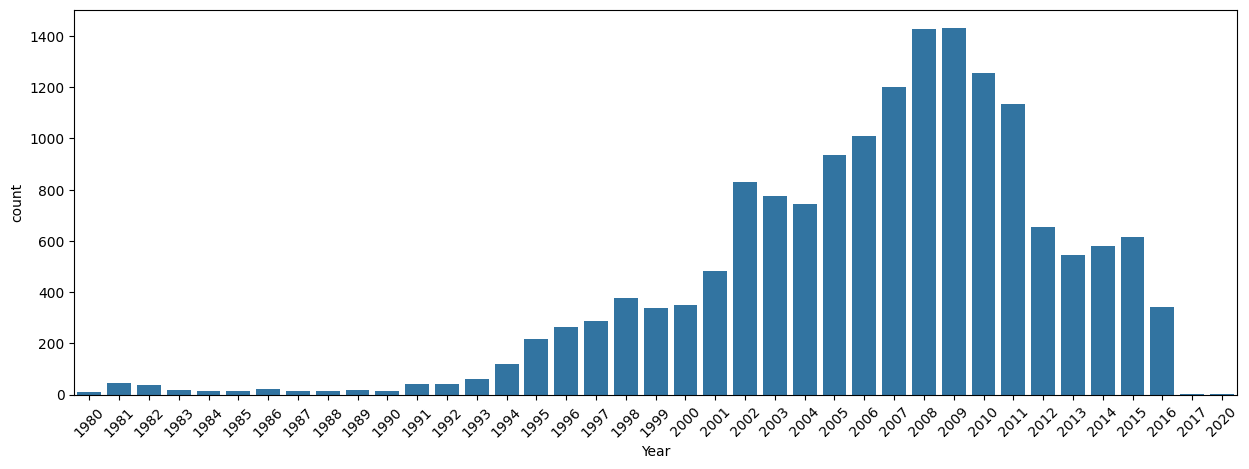

In [20]:
df = df.dropna() # избавляемся от пустот
df['Year'] = round(df['Year']).astype('int')
plt.figure(figsize=(15, 5))
sns.countplot(x = df['Year']) # количество встречаемых лет
plt.xticks(rotation=45) # поворот подписей лет на 45 градусов
sns.despine # убирает лишние outputs

In [21]:
df.groupby(df['Platform'], as_index = False)[['Name']].count().sort_values('Name', ascending=False).head()

,Platform,Name
4,DS,2131
16,PS2,2127
17,PS3,1304
26,Wii,1290
28,X360,1234


In [22]:
platforms = df['Platform'].value_counts(normalize=True) \
                          .mul(100) \
                          .to_frame('pct') # считаем долю встречаемости в %
platforms.query("pct > 7") \
         .index \
         .to_list() # выводим в виде списка те платформы, у которых частота встречаемости более 7%

['DS', 'PS2', 'PS3', 'Wii', 'X360', 'PSP', 'PS']

In [23]:
df['Publisher'].mode() # издатели, игры которых встречаются в датасете чаще всего

0    Electronic Arts
Name: Publisher, dtype: str

In [24]:
df['Publisher'].describe() # то же самое через describe()

count               16291
unique                576
top       Electronic Arts
freq                 1339
Name: Publisher, dtype: object

In [ ]:
df_filt = df[df['Publisher'].str.contains("Nintendo", case=False)] # среднее, медиана, ст.отклонениме по играм Nintendo
df_filt[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].agg(['mean', 'median', 'std'])

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
mean,1.172055,0.601006,0.653721,0.136767,2.563836
median,0.375000,0.120000,0.280000,0.030000,0.920000
std,2.989913,1.743953,1.063110,0.464170,5.676925


In [27]:
df_filt_genre = df_filt.groupby(df_filt['Genre'], as_index=False)['JP_Sales'] \
        .agg(['median','mean', lambda x: round(x.quantile(0.75) - x.quantile(0.25), 3)]) \
        .rename(columns={'<lambda_0>': 'IQR'})
df_filt_genre

,Genre,median,mean,IQR
0,Action,0.170,0.373846,0.380
1,Adventure,0.090,0.257429,0.200
2,Fighting,0.500,0.830000,1.232
3,Misc,0.250,0.552500,0.680
4,Platform,0.540,0.922162,0.855
5,Puzzle,0.255,0.501216,0.523
6,Racing,0.340,0.789730,0.790
7,Role-Playing,0.360,0.970952,0.580
8,Shooter,0.130,0.251250,0.205
9,Simulation,0.390,0.844643,0.895


<Axes: xlabel='Genre', ylabel='JP_Sales'>

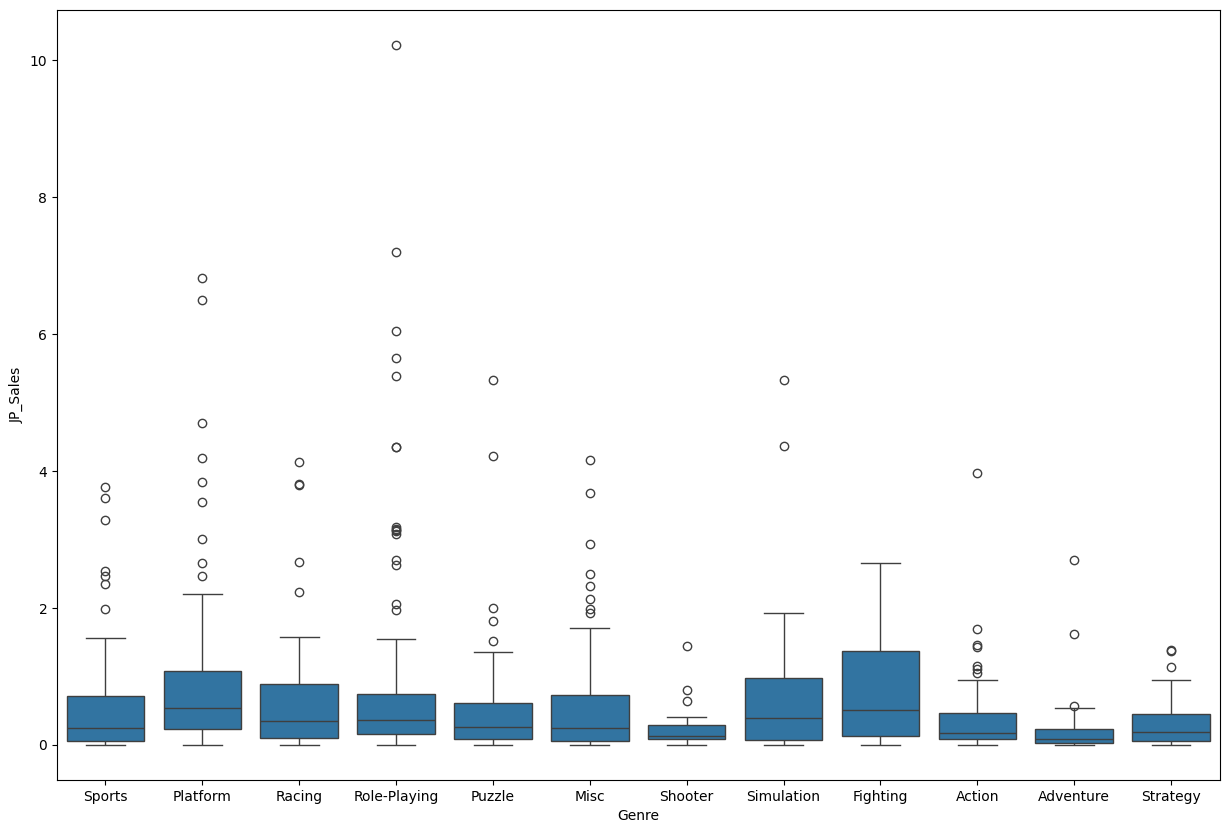

In [29]:
plt.figure(figsize=(15, 10))
sns.boxplot(data = df_filt, x = 'Genre', y = 'JP_Sales') # строим график продаж Nintendo в Японии по жанрам 

<Axes: xlabel='Year', ylabel='Global_Sales'>

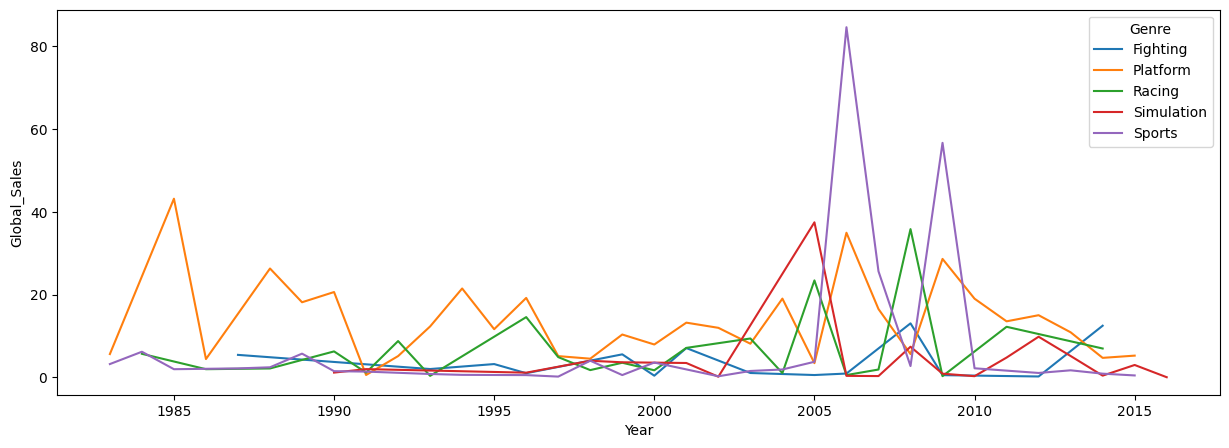

In [ ]:
df_filt_genre = df_filt[df_filt['Genre'].isin(['Fighting','Simulation','Platform','Racing','Sports'])].groupby(['Genre', 'Year'], as_index=False)['Global_Sales'].sum()
plt.figure(figsize=(15,5))
sns.lineplot(data=df_filt_genre, x = 'Year', y = 'Global_Sales', hue = 'Genre')
# игры жанра Sports были наиболее популярныж. в 2005-2010 гг